In [30]:
############### SETUP ############### 

import sys
sys.path.insert(0, '../src')  # Use relative path and insert at beginning to prioritize local version

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import FuncAnimation
from PySPIDER.commons.library import Observable
from PySPIDER.discrete.process_library_terms import SRDataset

In [2]:
############### FUNCTION DEFINITIONS ############### 

## ONE OF THESE SMOOTHS IN SPACE, THE OTHER IN TIME?

from scipy import ndimage
from scipy.signal import windows

# Tunable window size for smoothing
sigma = 400 # 400  # Adjust this parameter to control smoothing strength

def smooth_along_time_axis(data, sigma):
    """
    Apply Gaussian smoothing along the time axis (axis 2) of the data.
    
    Parameters:
    - data: array with shape (particles, spatial_dims, time_steps)
    - sigma: std. dev of the Gaussian smoothing window
    
    Returns:
    - smoothed_data: same shape as input, smoothed along time axis
    """
    # Create a 1D Gaussian window that goes to zero at edges
    window_size = sigma * 6 # number of points
    gaussian_window = windows.gaussian(window_size, sigma) # just makes a gaussian
    gaussian_window = gaussian_window / np.sum(gaussian_window)  # Normalize
    
    # Apply 1D convolution along the time axis (axis=2) for each particle and spatial dimension
    smoothed_data = np.zeros_like(data)
    
    for particle in range(data.shape[0]): # loop over particles
        for spatial_dim in range(data.shape[1]): # loop over x and y coordinates
            # Apply 1D convolution with 'same' mode to preserve time series length
            smoothed_data[particle, spatial_dim, :] = np.convolve(
                data[particle, spatial_dim, :], 
                gaussian_window, 
                mode='same'
            )
    
    return smoothed_data

# Alternative implementation using scipy.ndimage for potentially better performance
def smooth_along_time_axis_ndimage(data, sigma):
    """
    Alternative implementation using scipy.ndimage.gaussian_filter1d
    """
    #window_size = sigma * 6.0  # Convert window size to sigma for Gaussian
    
    # Apply Gaussian filter along axis 2 (time axis)
    smoothed_data = ndimage.gaussian_filter1d(data, sigma=sigma, axis=2, mode='nearest')
    
    return smoothed_data

In [3]:
############### LOAD DATA ############### 

data = np.load('positions_rho_0.30_savefreq_3.npz', allow_pickle=True)
positions_orig = data['positions']
vs_orig = data['vs']
deltat = data['deltat']
dims = data['dims']

del data

print(positions_orig.shape, vs_orig.shape, deltat, dims)

Np, nt = positions_orig.shape[0], positions_orig.shape[2] # NUMBER OF PARTICLES, NUMBER OF TIMESTEPS
world_size = np.array([dims[0], dims[1], nt])

(9600, 2, 10000) (9600, 2, 10000) 2.539543411945013 [248.66604111 248.66604111]


In [4]:
############### GET FIELD DATA ############### 

smooth_trajectories = True
edit_positions = True


if smooth_trajectories:
    # Apply smoothing ONLY to velocities to avoid periodic boundary artifacts
    print(f"Applying Gaussian smoothing to velocities with sigma {sigma}...")
    print(f"Original shapes - positions: {positions_orig.shape}, vs: {vs_orig.shape}")

    # Smooth only the velocities
    # vbar = smooth_along_time_axis_ndimage(vs_orig, sigma) # vs_orig is particle data. vbar is also particle data. this is all particle data
    vbar = smooth_along_time_axis(vs_orig, sigma)
    vprime = vs_orig - vbar
    vprimebar = smooth_along_time_axis(vprime**2, sigma)

    # Compute positions by integrating smoothed velocities with periodic boundaries
    def integrate_velocities_periodic(initial_positions, velocities, dt, domain_size):
        """
        Integrate velocities to get positions with periodic boundary conditions.
        
        Parameters:
        - initial_positions: starting positions at t=0, shape (particles, spatial_dims)
        - velocities: velocity time series, shape (particles, spatial_dims, time_steps)
        - dt: time step
        - domain_size: size of periodic domain [Lx, Ly]
        
        Returns:
        - positions: integrated positions with periodic wrapping
        """
        positions = np.zeros_like(velocities)
        positions[:, :, 0] = initial_positions
        
        for t in range(1, velocities.shape[2]):
            # Integrate: x(t+dt) = x(t) + v(t) * dt
            positions[:, :, t] = positions[:, :, t-1] + velocities[:, :, t-1] * dt
            
            # Apply periodic boundary conditions
            for dim in range(2):  # x and y dimensions
                # Wrap positions that exceed domain boundaries
                positions[:, dim, t] = np.mod(positions[:, dim, t], domain_size[dim])
        
        return positions

    if edit_positions:
        print("Computing positions by integrating smoothed velocities...")
        positions = integrate_velocities_periodic(
            initial_positions=positions_orig[:, :, 0], 
            velocities=vs_orig,  ## SHOULD IT NOT BE VBAR?
            dt=deltat, 
            domain_size=dims
        ) 
    else:
        positions = positions_orig

    del positions_orig, vs_orig

else: # do no smoothing
  positions = positions_orig
  vs = vs_orig


# subsampling
subsample_factor = 5
end_shot = 2500
positions = positions[:, :, :end_shot:subsample_factor]
if smooth_trajectories:
    vprime = vprime[:, :, :end_shot:subsample_factor]
    vbar = vbar[:, :, :end_shot:subsample_factor]
    vprimebar = vprimebar[:, :, :end_shot:subsample_factor]
else:
    vs = vs[:, :, :end_shot:subsample_factor]
deltat *= subsample_factor
nt = positions.shape[2]
world_size = np.array([dims[0], dims[1], nt])

if smooth_trajectories:
    print(f"Final shapes - positions: {positions.shape}, vprime: {vprime.shape}, vbar: {vbar.shape}, vprimebar: {vprimebar.shape}")
else:
    print(f"Final shapes - positions: {positions.shape}, vs: {vs.shape}")
print(deltat, dims)


Applying Gaussian smoothing to velocities with sigma 400...
Original shapes - positions: (9600, 2, 10000), vs: (9600, 2, 10000)
Computing positions by integrating smoothed velocities...
Final shapes - positions: (9600, 2, 500), vprime: (9600, 2, 500), vbar: (9600, 2, 500), vprimebar: (9600, 2, 500)
12.697717059725065 [248.66604111 248.66604111]


In [5]:
############### DEFINE SPIDER LIBRARIES AND STUFF ############### 

## AM I TIME SMOOTHING MULTIPLE TIMES????


def smooth_data_scalar(data, sigma):
    """
    Alternative implementation using scipy.ndimage.gaussian_filter1d
    this is just smooth_along_time_axis_ndimage but for scalar data. Ie, data that is N x T, rather than N x dim x T
    """
    #window_size = sigma * 6.0  # Convert window size to sigma for Gaussian
    
    # Apply Gaussian filter along axis 2 (time axis)
    smoothed_data = ndimage.gaussian_filter1d(data, sigma=sigma, axis=1, mode='nearest')
    
    return smoothed_data
    
smooth_cg_fields = not smooth_trajectories

# create temperature/pressure tensor, but just the trace
Pxx = smooth_data_scalar( vprime[:,0,:]*vprime[:,0,:] , sigma)
Pxy = smooth_data_scalar( vprime[:,0,:]*vprime[:,1,:] , sigma)
Pyy = smooth_data_scalar( vprime[:,1,:]*vprime[:,1,:] , sigma)
p1 = np.stack((Pxx, Pxy), axis=1) # indexed as x,y,t,vector_component
p2 = np.stack((Pxy, Pyy), axis=1)
#del Pxx; del Pxy; del Pyy
P = np.stack((p1, p2), axis=2)
del p1; del p2
# P = Pxx + Pyy
# P = smooth_data_scalar( vprime[:,0,:]*vprime[:,0,:] + vprime[:,1,:]*vprime[:,1,:] , sigma)

data_dict = {}
if not smooth_trajectories:
    data_dict['v'] = vs
    v_obs = Observable(string='v', rank=1)
    observables = [v_obs]
else:
    data_dict['vbar'] = vbar
    data_dict['v\''] = vprime
    data_dict['P'] = P
    data_dict['v\'v\'bar'] = vprimebar
    pbar_obs = Observable(string='P', rank=2, can_commute_indices = True, antisymmetric = False)
    # pbar_obs = Observable(string='P', rank=0)
    vbar_obs = Observable(string='vbar', rank=1)
    vprime_obs = Observable(string='v\'', rank=1)
    vprimebar_obs = Observable(string='v\'v\'bar', rank=1)
    observables = [vbar_obs, vprime_obs, vprimebar_obs, pbar_obs]

# fix random seed
np.random.seed(1)

# initial setup of dataset
corr_L = 20 # the dataset size is like 250x250
corr_T = 50 # total time is dt*number of steps = 2.5 * 10000 = 25000; might wanna bump this up?
kernel_sigma = 15 # I THINK THIS IS THE SPATIAL COARSE GRAINING PARAMETER? TO GET FIELD DATA
if smooth_cg_fields:
    t_sigma = 40
else:
    t_sigma = 0
cg_res = 1
srd = SRDataset(world_size=world_size, data_dict=data_dict, particle_pos=positions, observables=observables, # this is in process_library_terms.py
rho_scale=Np/dims[0]/dims[1], irreps=SRDataset.all_rank2_irreps(), kernel_sigma=kernel_sigma, 
time_sigma=t_sigma, cg_res=cg_res, deltat=deltat, cutoff=6, wrap=True)
#v_est = np.mean(np.abs(vs))*2**0.5
#print(v_est)

# initialize libraries, domains, and weights
# srd.make_libraries(max_complexity=4, max_rho=2)
# srd.make_libraries(max_complexity=5, max_rho=2)
srd.make_libraries(max_complexity=3, max_rho=1, max_dt=1)
#srd.make_libraries(max_complexity=6, max_rho=2)
for irrep in srd.irreps:
    print(irrep, ":", len(srd.libs[irrep].terms))

dom_width = 30 # 0.1
dom_time = 50  # 30

Rank 0 : 13
Rank 1 : 8
Antisymmetric rank 2 : 6
Symmetric trace-free rank 2 : 11


In [6]:
for irrep in srd.irreps:
    print(f"The {irrep} library has {len(srd.libs[irrep].terms)} terms:")
    print(srd.libs[irrep].terms)
    print()


The Rank 0 library has 13 terms:
[ρ, ∂α² ρ, ∂t ρ, ρ[P_αα], ∂α ρ[v'v'bar_α], ρ[v'v'bar_α · v'v'bar_α], ∂α ρ[v'_α], ρ[v'_α · v'v'bar_α], ρ[v'_α · v'_α], ∂α ρ[vbar_α], ρ[v'v'bar_α · vbar_α], ρ[v'_α · vbar_α], ρ[vbar_α · vbar_α]]

The Rank 1 library has 8 terms:
[∂α ρ, ∂t ∂α ρ, ρ[v'v'bar_α], ∂t ρ[v'v'bar_α], ρ[v'_α], ∂t ρ[v'_α], ρ[vbar_α], ∂t ρ[vbar_α]]

The Antisymmetric rank 2 library has 6 terms:
[∂α ρ[v'v'bar_β], ∂α ρ[v'_β], ρ[v'_α · v'v'bar_β], ∂α ρ[vbar_β], ρ[v'v'bar_β · vbar_α], ρ[v'_β · vbar_α]]

The Symmetric trace-free rank 2 library has 11 terms:
[∂α ∂β ρ, ρ[P_αβ], ∂α ρ[v'v'bar_β], ρ[v'v'bar_α · v'v'bar_β], ∂α ρ[v'_β], ρ[v'_α · v'v'bar_β], ρ[v'_α · v'_β], ∂α ρ[vbar_β], ρ[v'v'bar_β · vbar_α], ρ[v'_β · vbar_α], ρ[vbar_α · vbar_β]]



In [7]:
############### MORE BASIC SPIDER STUFF ############### 

srd.make_domains(ndomains=30, domain_size=[dom_width, dom_width, dom_time], t_pad=t_sigma*3)
srd.make_weights(m=8, qmax=1)
#srd.set_LT_scale(L=corr_L, T=corr_L/v_est) # note that this line must go before make_library_matrices
srd.set_LT_scale(L=corr_L, T=corr_T) # note that this line must go before make_library_matrices
srd.make_library_matrices(debug=False,parallel=True,num_processors=20) #debug=False

In [8]:
############### Get a slice of the fields to visualize ############### 
import scipy

from scipy.stats._stats import gaussian_kernel_estimate
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from IPython.display import HTML

def coarse_grain_slice(t, sigma, field='rho', component=None):
    pt_pos = positions[:, :, t]
    weights = np.ones(pt_pos.shape[0], dtype=np.float64)
    if field == 'v':
        # weights *= vs[:, component, t]
        weights *= vbar[:, component, t]
    xx, yy = np.meshgrid(range(int(dims[0])), range(int(dims[1])))
    xi = np.vstack([xx.ravel(), yy.ravel()]).T

    if field == 'vprime':
        # weights *= vs[:, component, t]
        weights *= vprime[:, component, t]
    xx, yy = np.meshgrid(range(int(dims[0])), range(int(dims[1])))
    xi = np.vstack([xx.ravel(), yy.ravel()]).T

    sigma_sq = sigma ** 2
    # Check scipy version. If it's lower than 1.10, use inverse_covariance, otherwise use Cholesky
    if int(scipy.__version__.split(".")[0]) <= 1 and int(scipy.__version__.split(".")[1]) < 10:
        inv_cov = np.eye(2) / sigma_sq
    else:
        inv_cov = np.eye(2) * sigma_sq
        inv_cov = np.linalg.cholesky(inv_cov[::-1, ::-1]).T[::-1, ::-1]
    density = gaussian_kernel_estimate['double'](pt_pos, weights[:, None], xi, inv_cov,
                                                 np.float64)
    output = np.reshape(density[:, 0], xx.shape)
    return output

def DX(field):
    output = np.zeros_like(field)
    
    for i in range(1, vx_cg.shape[0]-1):
        for j in range(1, vx_cg.shape[1]-1):
            output[i,j] = (field[i+1,j] - field[i-1,j]) / 2
    return output

def DY(field):
    output = np.zeros_like(field)
    for i in range(1, vx_cg.shape[0]-1):
        for j in range(1, vx_cg.shape[1]-1):
            output[i,j] = (field[i,j+1] - field[i,j+1]) / 2
    return output

def CURL(x,y):
    return DX(y) - DY(x)

  
t = 100
# sigma = kernel_sigma
rho_cg = coarse_grain_slice(t, sigma, field='rho')
vx_cg = coarse_grain_slice(t, sigma, field='v', component=0)
vprimex_cg = coarse_grain_slice(t, sigma, field='vprime', component=0)
N = vx_cg.shape[0] 


    

In [9]:
## TO GET GENERAL MOVIES OF ANY FIELD ##

def coarse_grain_slice_general(t, sigma, field):
    # field ENTRY SHOULD BE PARTICLE DATA of shape (# of particles, timestep) - it should be 'scalar data'
    # essentially this script acts the density operator on a field to get spatiotemporal data
    pt_pos = positions[:, :, t] # positions = (particles, coordinate (x,y), timestep), so this gets the particles at time t
    weights = np.ones(pt_pos.shape[0], dtype=np.float64)
    
    weights *= field[:, t]
    xx, yy = np.meshgrid(range(int(dims[0])), range(int(dims[1])))
    xi = np.vstack([xx.ravel(), yy.ravel()]).T

    sigma_sq = sigma ** 2
    # Check scipy version. If it's lower than 1.10, use inverse_covariance, otherwise use Cholesky
    if int(scipy.__version__.split(".")[0]) <= 1 and int(scipy.__version__.split(".")[1]) < 10:
        inv_cov = np.eye(2) / sigma_sq
    else:
        inv_cov = np.eye(2) * sigma_sq
        inv_cov = np.linalg.cholesky(inv_cov[::-1, ::-1]).T[::-1, ::-1]
    density = gaussian_kernel_estimate['double'](pt_pos, weights[:, None], xi, inv_cov,
                                                 np.float64)
    output = np.reshape(density[:, 0], xx.shape)
    return output

def coarse_grain_movie(sigma,field,N,T):
    # N is spatial domain length. #T is temporal domain length
    output = np.zeros((N,N,T))
    for tt in range(0 , T):
        frame_slice = coarse_grain_slice_general(tt, sigma, field)
        output[:,:,tt] = frame_slice
    return output

In [10]:
# sigma = 400
print(sigma)
Pxx = smooth_data_scalar( vprime[:,0,:]*vprime[:,0,:] , sigma)
Pyy = smooth_data_scalar( vprime[:,1,:]*vprime[:,1,:] , sigma)

400


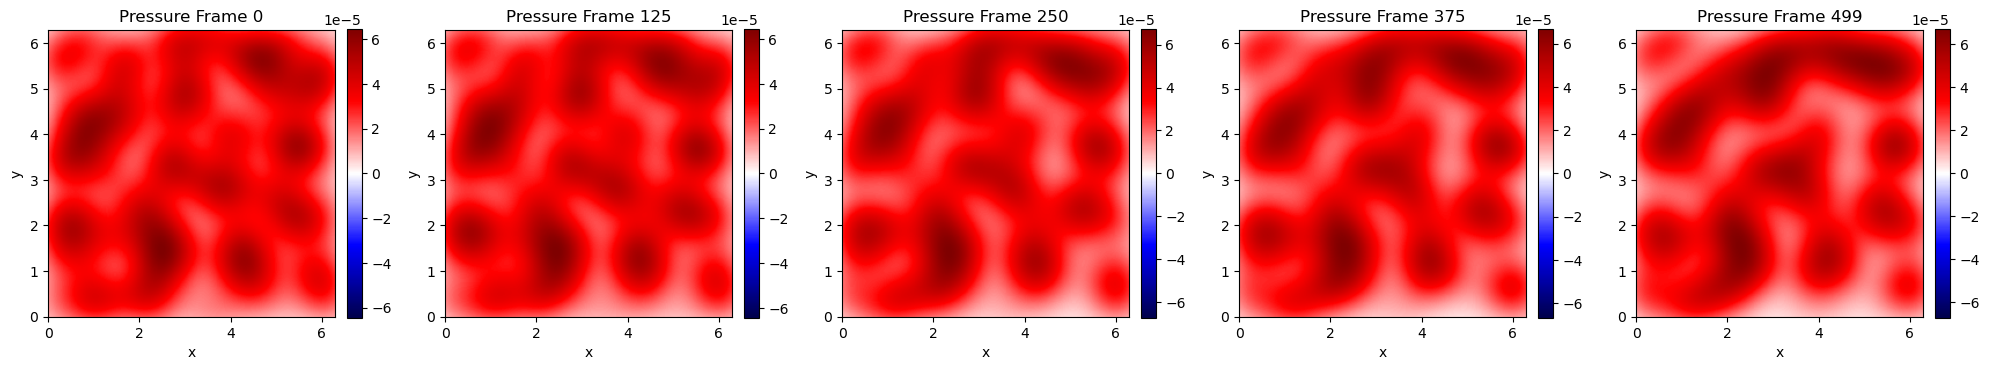

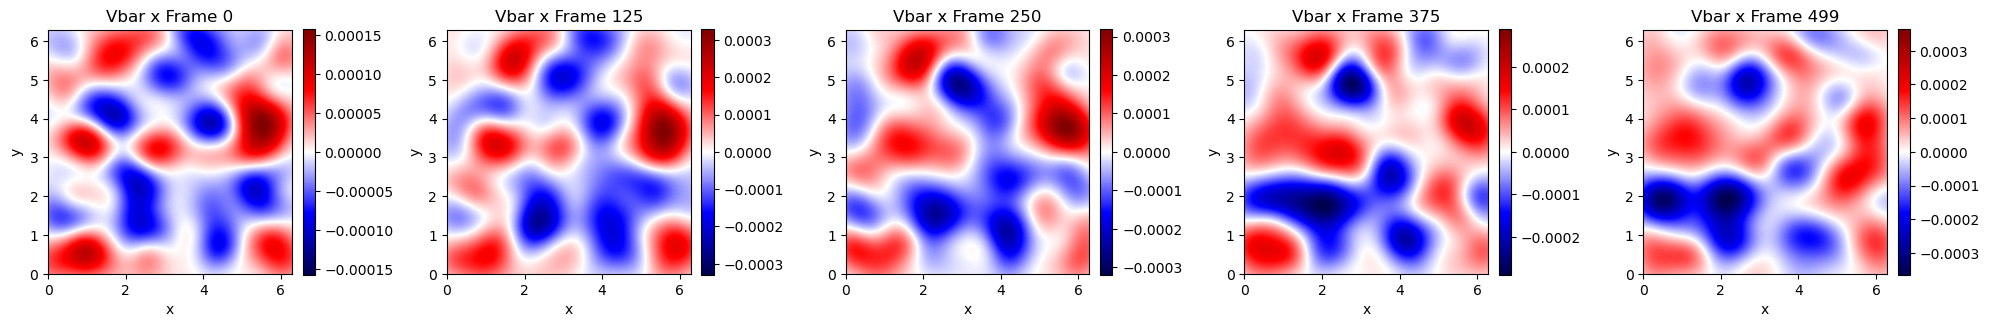

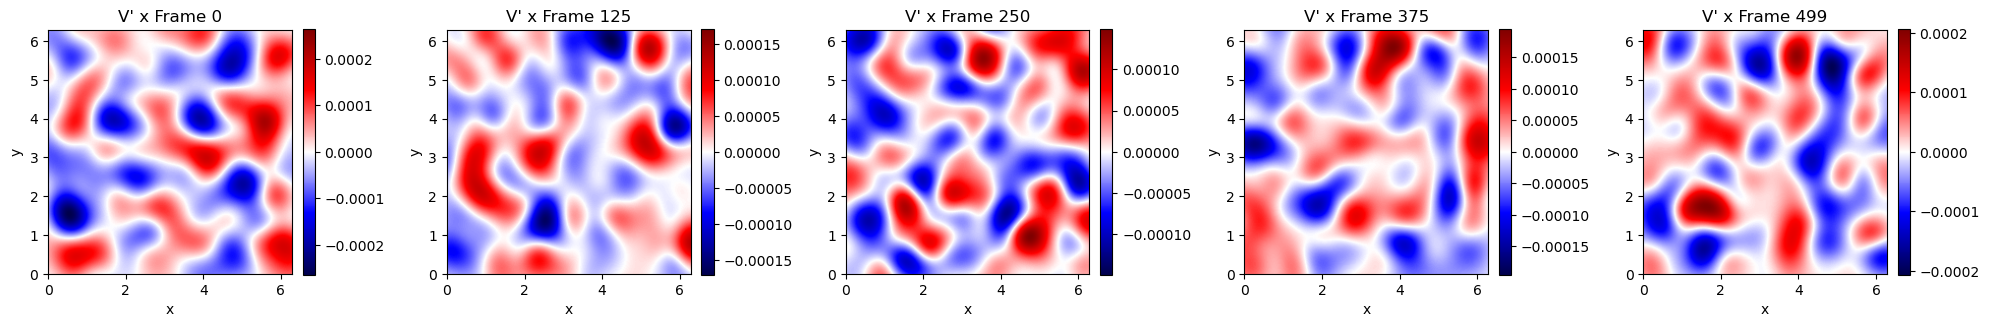

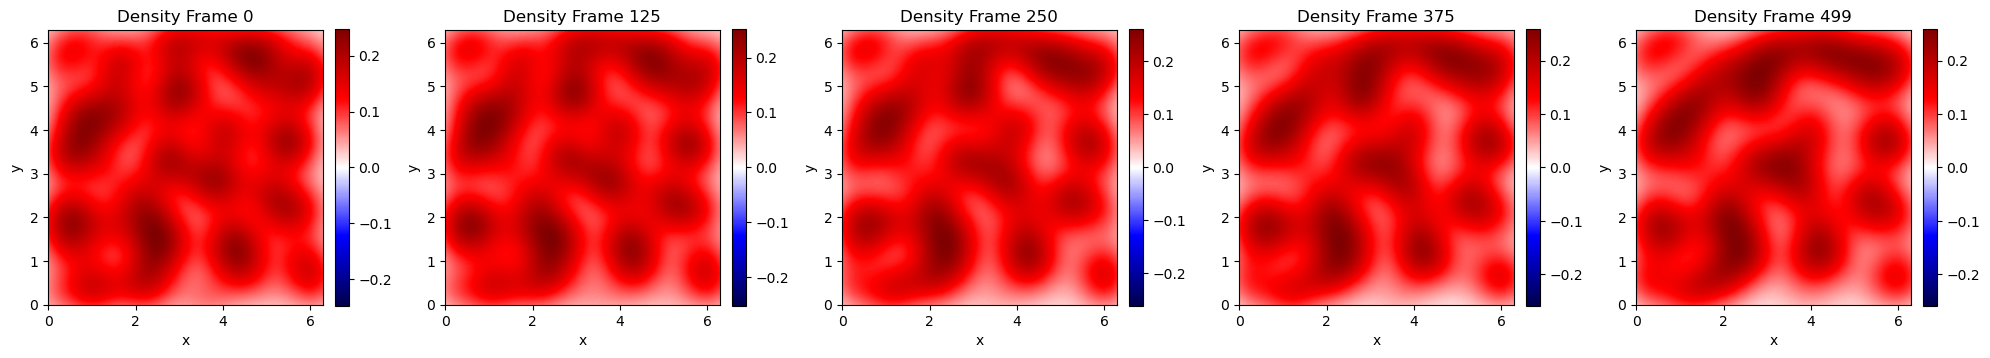

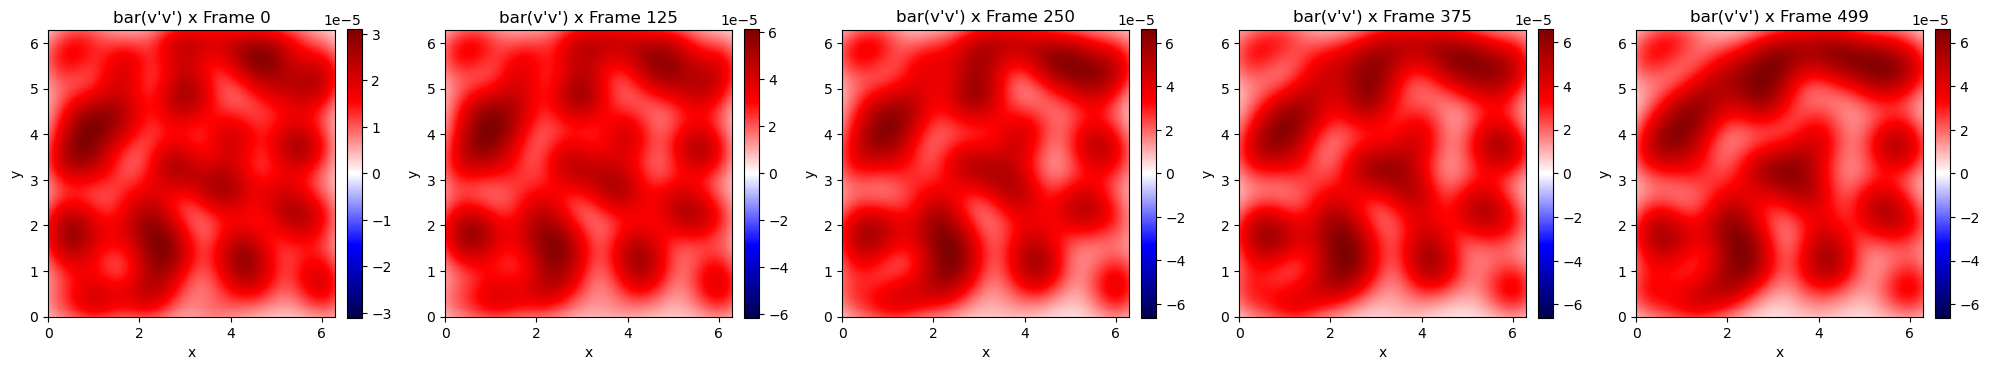

In [19]:
# --- Pressure trace (Pxx) sample frames ---
field = Pxx
sample_indices = [0, int(world_size[2])//4, int(world_size[2])//2, 3*int(world_size[2])//4, int(world_size[2])-1]
snapshots = []
for idx in sample_indices:
    frame = coarse_grain_slice_general(idx, kernel_sigma, field)
    snapshots.append(frame)
fig, axs = plt.subplots(1, len(sample_indices), figsize=(4*len(sample_indices), 4))
for i, (idx, frame) in enumerate(zip(sample_indices, snapshots)):
    ax = axs[i] if len(sample_indices) > 1 else axs
    im = ax.imshow(frame, cmap='seismic', origin='lower',
                   extent=[0, 2*np.pi, 0, 2*np.pi],
                   vmin=-np.max(np.abs(frame)), vmax=np.max(np.abs(frame)))
    ax.set_title(f'Pressure Frame {idx}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# --- vbar (mean velocity x) sample frames ---
vbar_snapshots = []
for idx in sample_indices:
    vbar_frame = coarse_grain_slice(idx, kernel_sigma, field='v', component=0)
    vbar_snapshots.append(vbar_frame)
fig, axs = plt.subplots(1, len(sample_indices), figsize=(4*len(sample_indices), 4))
for i, (idx, frame) in enumerate(zip(sample_indices, vbar_snapshots)):
    ax = axs[i] if len(sample_indices) > 1 else axs
    im = ax.imshow(frame, cmap='seismic', origin='lower',
                   extent=[0, 2*np.pi, 0, 2*np.pi],
                   vmin=-np.max(np.abs(frame)), vmax=np.max(np.abs(frame)))
    ax.set_title(f'Vbar x Frame {idx}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# --- vprime (fluctuating velocity x) sample frames ---
vprime_snapshots = []
for idx in sample_indices:
    vprime_frame = coarse_grain_slice(idx, kernel_sigma, field='vprime', component=0)
    vprime_snapshots.append(vprime_frame)
fig, axs = plt.subplots(1, len(sample_indices), figsize=(4*len(sample_indices), 4))
for i, (idx, frame) in enumerate(zip(sample_indices, vprime_snapshots)):
    ax = axs[i] if len(sample_indices) > 1 else axs
    im = ax.imshow(frame, cmap='seismic', origin='lower',
                   extent=[0, 2*np.pi, 0, 2*np.pi],
                   vmin=-np.max(np.abs(frame)), vmax=np.max(np.abs(frame)))
    ax.set_title(f"V' x Frame {idx}")
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# --- Density sample frames ---
rho_snapshots = []
for idx in sample_indices:
    rho_frame = coarse_grain_slice(idx, kernel_sigma, field='rho')
    rho_snapshots.append(rho_frame)
fig, axs = plt.subplots(1, len(sample_indices), figsize=(4*len(sample_indices), 4))
for i, (idx, frame) in enumerate(zip(sample_indices, rho_snapshots)):
    ax = axs[i] if len(sample_indices) > 1 else axs
    im = ax.imshow(frame, cmap='seismic', origin='lower',
                   extent=[0, 2*np.pi, 0, 2*np.pi],
                   vmin=-np.max(np.abs(frame)), vmax=np.max(np.abs(frame)))
    ax.set_title(f'Density Frame {idx}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# --- bar(v'v') sample frames ---
# vprimebar is (particles, spatial_dim, time)
# We'll show the x component (vprimebar[:,0,:])
vprimebar_field = vprimebar[:,0,:]
vprimebar_snapshots = []
for idx in sample_indices:
    vprimebar_frame = coarse_grain_slice_general(idx, kernel_sigma, vprimebar_field)
    vprimebar_snapshots.append(vprimebar_frame)
fig, axs = plt.subplots(1, len(sample_indices), figsize=(4*len(sample_indices), 4))
for i, (idx, frame) in enumerate(zip(sample_indices, vprimebar_snapshots)):
    ax = axs[i] if len(sample_indices) > 1 else axs
    im = ax.imshow(frame, cmap='seismic', origin='lower',
                   extent=[0, 2*np.pi, 0, 2*np.pi],
                   vmin=-np.max(np.abs(frame)), vmax=np.max(np.abs(frame)))
    ax.set_title(f"bar(v'v') x Frame {idx}")
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [31]:
############### REGRESSION ############### 

from PySPIDER.commons.identify_models import interleave_identify
from PySPIDER.commons.sparse_reg_bf import Scaler, Initializer, ModelIterator, Residual, Threshold

import importlib
import PySPIDER.commons.sr_utils as sr_utils
importlib.reload(sr_utils)

libs = srd.libs

reg_opts_list = []
for irrep in srd.irreps:
    #print(np.linalg.norm(libs[irrep].Q, axis=0))
    # for regression we now need to construct a Scaler, Initializer, ModelIterator, and Threshold
    scaler = Scaler(sub_inds=None, char_sizes=libs[irrep].col_weights, row_norms=None, unit_rows=True, train_fraction=1)
    init = Initializer(method='combinatorial', start_k=3)
    #init = Initializer(method='combinatorial', start_k=9999)
    #init = Initializer(method='power', start_k=10)
    #res = Residual(residual_type='fixed_column', anchor_col=0)
    #res = Residual(residual_type='dominant_balance')
    #res = Residual(residual_type='matrix_relative')
    res = Residual(residual_type='hybrid')
    
    iterator = ModelIterator(max_k=10, backward_forward=True, max_passes=3)
    #iterator = ModelIterator(max_k=len(libs[irrep].terms), backward_forward=False, max_passes=1)
    thres = Threshold(threshold_type='jump', gamma=1.5, delta=1e-8, n_terms=None)
    #thres = Threshold(threshold_type='information', ic=AIC)
    
    opts = {'scaler': scaler, 'initializer': init, 'residual': res,
            'model_iterator': iterator, 'threshold': thres}
    opts['verbose'] = False
    opts['inhomog'] = False
    opts['inhomog_col'] = None
    reg_opts_list.append(opts)


eqs, lambdas, reg_results, derived_eqs, excluded_terms = interleave_identify([libs[i] for i in srd.irreps], 
    #reg_opts_list, threshold=1e-6, experimental=True, report_accuracy=True,
    reg_opts_list, threshold=5e-2, experimental=True, report_accuracy=True, max_equations=99,
    #print_opts={'num_format': '{0:.3g}', 'latex_output': True}
)

--- WORKING ON LIBRARY WITH IRREP Rank 0 AT COMPLEXITY 1 ---
--- WORKING ON LIBRARY WITH IRREP Rank 1 AT COMPLEXITY 1 ---
--- WORKING ON LIBRARY WITH IRREP Antisymmetric rank 2 AT COMPLEXITY 1 ---
--- WORKING ON LIBRARY WITH IRREP Symmetric trace-free rank 2 AT COMPLEXITY 1 ---
--- WORKING ON LIBRARY WITH IRREP Rank 0 AT COMPLEXITY 2 ---


RuntimeError: smallest_sv failed for all Tikhonov regularization offsets

In [ ]:
from commons.utils import *

lib1 = srd.libs[srd.irreps[1]]
for match in regex_find(lib1.terms, r"∂β ρ[v'_α · v'_β]"):
    print(match)
    term = lib1.Q[:, match[0]]
    print(np.linalg.norm(term))

# first index of the print output is the term #

# 3 is symmetric tensor, 2 is anti, 1 is vector, 0 is scalar

for i, term, size in zip(list(range(len(lib1.terms))), lib1.terms, lib1.col_weights):
    print(i, term, size, term.complexity)

In [ ]:
from commons.sparse_reg_bf import *
from commons.identify_models import *

scaler = Scaler(sub_inds=None, char_sizes=lib1.col_weights, row_norms=None, train_fraction=1, unit_rows=True)
init = Initializer(method='combinatorial', start_k=2)
res = Residual(residual_type='dominant_balance')
# res = Residual(residual_type='matrix_relative')

iterator = ModelIterator(max_k=10, backward_forward=True, max_passes=10)
thres = Threshold(threshold_type='jump', gamma=1.2, delta=1e-8, n_terms=3)

opts = {'scaler': scaler, 'initializer': init, 'residual': res,
        'model_iterator': iterator, 'threshold': thres}

opts['inhomog'] = True
opts['inhomog_col'] = 25 # 35

# remove_terms = [21,35,27,33] # WE WANT 28
# remove_terms = [35,13,25]
remove_terms = [32,19]
for term in remove_terms:
    if term in opts['scaler'].sub_inds:
        opts['scaler'].sub_inds.remove(term) 
opts['scaler'].reset_inds(opts['scaler'].sub_inds)

reg_result = sparse_reg_bf(lib1.Q, **opts)
zipped = [(lib1.terms[i], c) for i, c in enumerate(reg_result.xi) if c != 0]
eqn = Equation([e[0] for e in zipped], [e[1] for e in zipped])

print(eqn, "; residual:", reg_result.lambd)